The following is an alternative method that uses compound maps for the intial maps rather than the nearest neighbour search.

In [2]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import pickle as p
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm
import meshplot as mp

import polyscope as ps

INTERVAL = 3
BONUS = 2


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Plotting Functions

quick note:


**fm_display()** - displays the C matrix and the pointwise visualisation between mesh 1 and mesh 2.


**double_fm_display()** - displays the C matrix from both ZoomOut Refinerment methods and the pointwise visualisation of both maps on mesh 2 ONLY.

In [ ]:
# Alternative Plotting Functions
def double_pcd_plot_ps(myCloud1, myCloud2, cmap1=None, cmap2=None,
                       offset1=np.array([0, 0, 0]), 
                       offset2=np.array([1.5, 0, 0])):

    ps.init()

    pts1 = np.asarray(myCloud1.vertlist)
    pts2 = np.asarray(myCloud2.vertlist)

    # Register clouds with offsets (visual only, does not change ANY intrinsic data only for vis)
    ps.register_point_cloud("cloud_1", pts1 + offset1)
    ps.register_point_cloud("cloud_2", pts2 + offset2)

    if cmap1 is not None:
        ps.get_point_cloud("cloud_1").add_color_quantity("cmap1", cmap1, defined_on='vertices')

    if cmap2 is not None:
        ps.get_point_cloud("cloud_2").add_color_quantity("cmap2", cmap2, defined_on='vertices')

    ps.show()


def double_mesh_plot_ps(myMesh1, myMesh2, cmap1=None, cmap2=None,
                        offset1=np.array([0, 0, 0]),
                        offset2=np.array([1.5, 0, 0])):

    ps.init()

    v1 = np.asarray(myMesh1.vertlist)
    f1 = np.asarray(myMesh1.facelist)

    v2 = np.asarray(myMesh2.vertlist)
    f2 = np.asarray(myMesh2.facelist)

    ps.register_surface_mesh("mesh_1", v1 + offset1, f1)
    ps.register_surface_mesh("mesh_2", v2 + offset2, f2)

    if cmap1 is not None:
        ps.get_surface_mesh("mesh_1").add_color_quantity("cmap1", cmap1, defined_on='vertices')

    if cmap2 is not None:
        ps.get_surface_mesh("mesh_2").add_color_quantity("cmap2", cmap2, defined_on='vertices')

    ps.show()
    
# Meshplot Display Function
def double_plot_meshplot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

# Normalise maps for display
def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

# For Display
def fm_display(i, j, mesh_1, mesh_2, fm_map, mesh_display=False, other_view=False):
    
    print(f"map shape: {fm_map.shape}")
    plt.matshow(fm_map)
    plt.title(f"C mat - mesh {i+1} -> mesh {j+1}")
    plt.show()

    if mesh_display:
        p2p_21 = spectral.convert.mesh_FM_to_p2p(fm_map, mesh_1, mesh_2) # need to look at this function properly

        cmap_1 = visu(mesh_1.vertlist)
        cmap_2 = cmap_1[p2p_21]

        if other_view:
            double_mesh_plot_ps(mesh_1, mesh_2, cmap_1, cmap_2)
        else:
            double_plot_meshplot(mesh_1, mesh_2, cmap_1, cmap_2)

def double_fm_display(ind_1, ind_2, maps1, maps2, mesh_display=False, meshes=None, other_view=False):
    
    fm_12_1 = maps1[(ind_1, ind_2)]
    
    print(f"map shape: {fm_12_1.shape}")
    plt.matshow(fm_12_1)
    plt.title(f"C Map 1 - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()


    fm_12_2 = maps2[(ind_1, ind_2)]
    
    print(f"map shape: {fm_12_2.shape}")
    plt.matshow(fm_12_2)
    plt.title(f"C Maps 2 - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
        cmap_1 = visu(mesh1.vertlist)

        p2p_21_1 = spectral.convert.mesh_FM_to_p2p(fm_12_1, mesh1, mesh2)
        p2p_21_2 = spectral.convert.mesh_FM_to_p2p(fm_12_2, mesh1, mesh2)

        cmap_2_1 = cmap_1[p2p_21_1]
        cmap_2_2 = cmap_1[p2p_21_2]

        if other_view:
            double_mesh_plot_ps(mesh2, mesh2, cmap_2_1, cmap_2_2)
        else:
            double_plot_meshplot(mesh2, mesh2, cmap_2_1, cmap_2_2)

NameError: name 'np' is not defined

# Step 1. Data Pre-Processing

### Loading and processing the meshes

In [3]:
def processed_TriMesh(mesh):

    # clean mesh
    mesh.remove_duplicated_vertices()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()

    verts, faces = np.asarray(mesh.vertices), np.asarray(mesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!

    return mesh_pyfm

In [4]:
path = os.path.abspath('render_meshes_10')

start_frame = 1
end_frame = 10
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

mesh_list = [processed_TriMesh(o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}.ply')) for frame in tqdm(frames, "Loading and Processing Meshes")]

Loading and Processing Meshes:   0%|          | 0/10 [00:00<?, ?it/s]

## Calculating Initial Maps

### Original Method - Nearest Neighbour Search

- Calculating the intial pointwise maps between each pair of shapes
    - Currently using nearest neighbours but will use sequential based compound maps as well later.

This is the method that **main.ipynb** uses.

In [5]:
def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

def create_intial_maps_dict(meshes, K=30):
    initial_maps_dict = {}
    n_meshes = len(meshes)

    for i in tqdm(range(n_meshes)):
        for j in range(n_meshes):
            
            if i == j: #or (j,i) in initial_maps_dict or (j,i) in initial_maps_dict: 
                continue # skip self-maps

            mesh_i, mesh_j = meshes[i], meshes[j]

            verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
            p2p_ji = initial_p2p_map(verts_j, verts_i)

            # Convert to functional map
            FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
            #FM_ji = FM_ij.T
        
            # Populate the dictionary
            initial_maps_dict[(i, j)] = FM_ij
            #initial_maps_dict[(j, i)] = FM_ji

    return initial_maps_dict

initial_maps_dict = create_intial_maps_dict(mesh_list)

  0%|          | 0/10 [00:00<?, ?it/s]

### Alternative method - Compounded Maps
For each mesh pair, if the map is within the interval, it is calculated regularly using the nearest neighbour search, otherwise a compound map is created. 

- This is the method used in this implementation, below is a visualisation that shows the differences to the original method

In [6]:
def optimised_dict(mesh_list, bidirectional=True, K=30):
    optimised_dict = {}
    n_meshes = len(mesh_list)

    # Step 1: Compute initial pairwise maps within the interval
    for i in tqdm(range(n_meshes)):
        source_mesh = mesh_list[i]

        for k in range(1, INTERVAL + 1):
            j = i + k 
            if j < n_meshes:
                target_mesh = mesh_list[j]

                # Compute initial maps
                verts_i, verts_j = np.asarray(source_mesh.vertices), np.asarray(target_mesh.vertices)
                p2p_ji = initial_p2p_map(verts_j, verts_i)

                # Convert to functional maps
                FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, source_mesh, target_mesh, dims=K)
                optimised_dict[(i, j)] = FM_ij

                if bidirectional:
                    p2p_ij = initial_p2p_map(verts_i, verts_j)
                    FM_ji = spectral.mesh_p2p_to_FM(p2p_ij, target_mesh, source_mesh, dims=K)
                    optimised_dict[(j, i)] = FM_ji

    # Step 2: Compound maps
    for i in tqdm(range(n_meshes)):
        for j in range(i + 2, n_meshes):
            if (i, j) in optimised_dict:
                continue

            # Compose all intermediate steps if they exist
            valid_chain = True
            chain = []
            for step in range(i, j):
                if (step, step + 1) not in optimised_dict:
                    valid_chain = False
                    break
                chain.append(optimised_dict[(step, step + 1)])

            if valid_chain and chain:
                FM_ij = chain[0]
                for next_FM in chain[1:]:
                    FM_ij = FM_ij @ next_FM
                optimised_dict[(i, j)] = FM_ij

                # If bidirectional, do the same in reverse
                if bidirectional:
                    rev_chain = []
                    for step in range(j, i, -1):
                        if (step, step - 1) not in optimised_dict:
                            valid_chain = False
                            break
                        rev_chain.append(optimised_dict[(step, step - 1)])
                    if valid_chain and rev_chain:
                        FM_ji = rev_chain[0]
                        for next_FM in rev_chain[1:]:
                            FM_ji = FM_ji @ next_FM
                        optimised_dict[(j, i)] = FM_ji

    return optimised_dict

compound_dict = optimised_dict(mesh_list)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

**visualisation**

note: The meshes plotted are both **ind_2**, unlike the previous visualisation. This is only to show the difference between the two maps on the same mesh.

map shape: (30, 30)


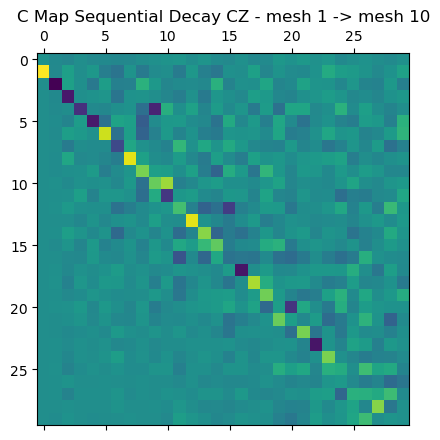

map shape: (30, 30)


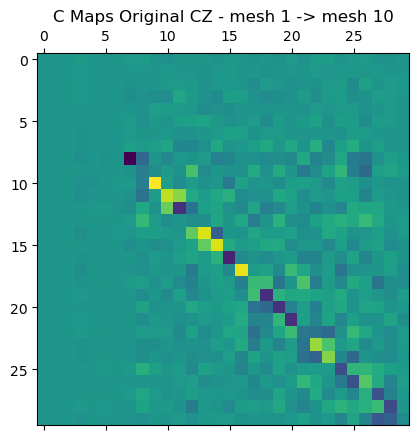

In [ ]:
ind1 = 0
ind2 = 9

double_fm_display(ind1, ind2, initial_maps_dict, compound_dict, mesh_display=True, meshes=mesh_list, other_view=False)

# Step 2. Creating the FMN model and CZ Refinement

In [8]:
from FMN_Edited import FMN_Edited

# Build the network
fmn_model_new = FMN_Edited(mesh_list, compound_dict.copy())

Setting 90 edges on 10 nodes.


In [ ]:
fmn_model_new.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='sequence decay',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True, bonus=BONUS, interval=INTERVAL)

Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
# To Save or Load Model
#save
with open("saved_maps/refined_commpound_maps.pkl", "wb") as f:
    p.dump(fmn_model_new.maps, f)

# load
# with open("saved_maps/refined_commpound_maps.pkl", "rb") as f:
#     fmn_model_new.maps = p.load(f)

### Visualisation

new map shape: (78, 78)


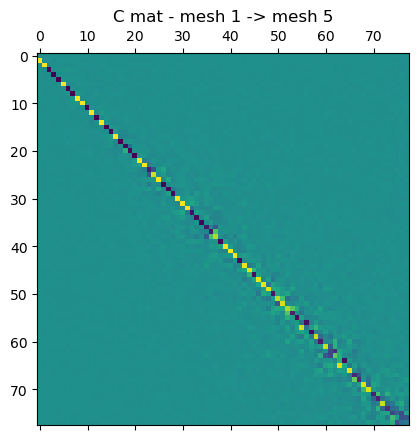

In [ ]:
ind_1 = 0
ind_2 = 4

new_maps_dict = fmn_model_new.maps

fm_display(ind_1, ind_2, new_maps_dict, mesh_display=True, meshes=mesh_list, other_view=False)

# Step 3. Evaluation

Setting up the original Consistent ZoomOut method as the ground truth for benchmarking.

In [23]:
from pyFM.FMN import FMN
fmn_model_old = FMN(mesh_list, compound_dict.copy())

Setting 90 edges on 10 nodes.


In [24]:
fmn_model_old.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='icsm',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True)

Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [25]:
# save
with open("original_CZ_compound_maps.pkl", "wb") as f:
    p.dump(fmn_model_old.maps, f)

# # load
# with open("original_CZ_compound_maps.pkl", "rb") as f:
#     fmn_model_old.maps = p.load(f)
#     #old_maps_dict = p.load(f)

### Visualisation

Visualisation
note: The meshes plotted are both **ind_2**, unlike the previous visualisation. This is only to show the difference between the two maps on the same mesh.

new map shape: (78, 78)


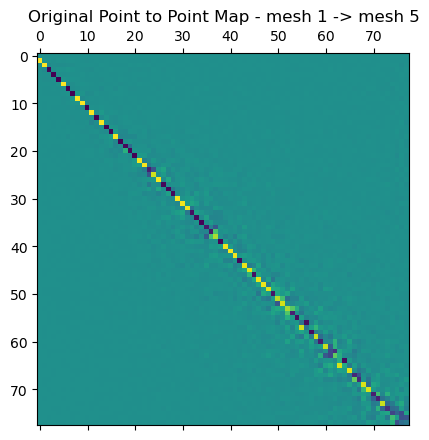

new map shape: (78, 78)


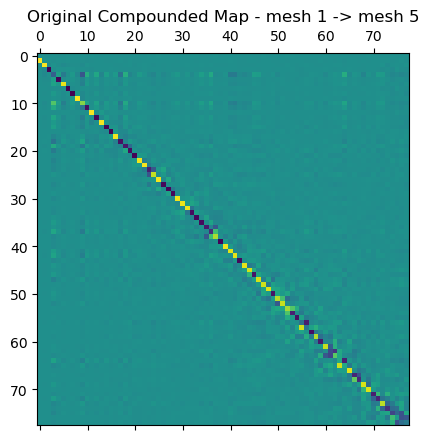

In [ ]:
ind_1 = 0
ind_2 = 4

new_maps_dict = fmn_model_new.maps
old_maps_dict = fmn_model_old.maps

double_fm_display(ind_1, ind_2, new_maps_dict, old_maps_dict, mesh_display=True, meshes=mesh_list, other_view=False)

### Method 1: Map Accuracy - Using Chamfer distance

In [ ]:
from scipy.spatial import KDTree

def normalise_scale(P):
    # 1. Center the cloud
    center = np.mean(P, axis=0)
    P_centered = P - center
   
    # 2. Calculate RMS distance from the center (size measure)
    rms_size = np.sqrt(np.mean(np.sum(P_centered**2, axis=1)))
   
    # 3. Normalize (avoid division by zero if all points are identical)
    if rms_size > 1e-6:
        P_normalised = P_centered / rms_size
    else:
        P_normalised = P_centered # Already very small/degenerate
       
    return P_normalised

def chamfer_distance(A, B):
    # Build a KD-Tree for efficient nearest neighbor search
    tree_B = KDTree(B)
    tree_A = KDTree(A)

    # Term 1: Distance from A to B (B is the target)
    # query returns: distances, indices
    dist_A_to_B, _ = tree_B.query(A)
    sum_A_to_B = np.sum(dist_A_to_B**2)
   
    # Term 2: Distance from B to A (A is the target)
    dist_B_to_A, _ = tree_A.query(B)
    sum_B_to_A = np.sum(dist_B_to_A**2)

    # Chamfer Distance (Averaged two-way squared distance)
    cd = (sum_A_to_B / len(A)) + (sum_B_to_A / len(B))
   
    return cd

def compare_chamfer_distance(p2p_map, source_mesh):

    src_points = np.asarray(source_mesh.vertices)
    mapped_points = src_points[p2p_map]

    # Normalize all matrices
    A_norm = normalise_scale(mapped_points)
    B_norm = normalise_scale(src_points)

    # Calculate CD for Method 1
    cd1 = chamfer_distance(A_norm, B_norm)
    return cd1


# old euclidean map error function
def euclidean_map_error(p2p_map, source_mesh, target_mesh):
    src_points = np.asarray(source_mesh.vertices)
    trgt_points = np.asarray(target_mesh.vertices)

    mapped_trgt_points = src_points[p2p_map]
    pointwise_errors = np.linalg.norm(trgt_points - mapped_trgt_points, axis=1) # distance accross each row

    return pointwise_errors

note: This takes a long time to run because of the spectral conversion for each pair being done 3 times.

In [ ]:
errors_new = {}
errors_old = {}
errors_compound = {}
new_maps_dict = fmn_model_new.maps
old_maps_dict = fmn_model_old.maps

for i in range(len(mesh_list)):
    for j in tqdm(range(len(mesh_list))):
        if i == j:
            continue

        mesh1, mesh2 = mesh_list[i], mesh_list[j]

        new_map_ij = new_maps_dict[(i, j)]
        initial_map_ij = old_maps_dict[(i, j)]
        compound_map_ij = compound_dict[(i, j)]

        new_p2p = spectral.convert.mesh_FM_to_p2p(new_map_ij, mesh1, mesh2)
        old_p2p = spectral.convert.mesh_FM_to_p2p(initial_map_ij, mesh1, mesh2)
        compound_p2p = spectral.convert.mesh_FM_to_p2p(compound_map_ij, mesh1, mesh2)

        err_new = compare_chamfer_distance(new_p2p, mesh1)
        err_old = compare_chamfer_distance(old_p2p, mesh1)
        err_compound = compare_chamfer_distance(old_p2p, mesh1)

        errors_new[(i, j)] = err_new
        errors_old[(i, j)] = err_old
        errors_compound[(i, j)] = err_compound

In [ ]:
list_errors_new = []
list_errors_old = []
list_errors_compounded = []

map_labels = []

for (i, j) in errors_new:
    list_errors_new.append(errors_new[(i, j)])
    list_errors_old.append(errors_old[(i, j)])
    list_errors_compounded.append(errors_compound[(i, j)])
    
    map_labels.append(f"{i}→{j}")

print(len(list_errors_new))

# Plot
plt.figure(figsize=(14,8))

plt.scatter(range(len(list_errors_old)), list_errors_old, c='tab:orange', label='Original Refinement', s=50, alpha=0.8)
plt.scatter(range(len(list_errors_compounded)), list_errors_compounded, c='tab:red', label='Initial Compound Maps', s=50, alpha=0.8)
plt.scatter(range(len(list_errors_new)), list_errors_new, c='tab:blue', label='Sequential Weighted Refinement', s=50, alpha=0.8)

plt.xticks(range(len(errors_new)), map_labels, rotation=90)
plt.ylabel("Chamfer Error on Target Mesh")
plt.title("Mapping Error per Mesh Pair")

# Legend below the x-axis
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.25, -0.1),  # position below the axis
    ncol=2,                       # number of columns
    frameon=False                 # optional: cleaner look
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave extra space for the legend
plt.show()

### Method 2: Cycle Consistentcy

In [ ]:
def check_cycle_consistency(map_ij, map_ji, i, j, show=False):
    compound = map_ji @ map_ij
    
    # Identity for shape Si
    identity = np.eye(map_ij.shape[0])
    elementwise_error = np.abs(identity - compound)
    
    if show:
        print(np.mean(elementwise_error))

        plt.matshow(elementwise_error, vmin=-1, vmax=1)
        plt.title(f"Bijectvity Error {i+1} -> {j+1} -> {i+1}")
        plt.colorbar()

        plt.show()

    return np.mean(elementwise_error)

bijectivity_new_errors = []
bijectivity_old_errors = []
map_labels = []

for i in range(len(mesh_list)):
    for j in tqdm(range(len(mesh_list))):
        if i == j:
            continue

        if i == 9 and j == 0: # Displays just the 10 -> 1 -> 10 map
            showw = True
        else:
            showw = False

        mesh1, mesh2 = mesh_list[i], mesh_list[j]
        
        new_map_ij = new_maps_dict[(i, j)]
        old_map_ij = old_maps_dict[(i, j)]

        new_map_ji = new_maps_dict[(j, i)]
        old_map_ji = old_maps_dict[(j, i)]

        err_new = check_cycle_consistency(new_map_ij, new_map_ji, i, j, showw)

        bijectivity_new_errors.append(err_new)
        bijectivity_old_errors.append(err_old)

        map_labels.append(f"{i}→{j}→{i}")

plt.figure(figsize=(14,8))

plt.scatter(range(len(bijectivity_new_errors)), bijectivity_new_errors, c='tab:blue', label='Sequential Weighted Refinement', s=50, alpha=0.8)

plt.xticks(range(len(bijectivity_new_errors)), map_labels, rotation=90)
plt.ylabel("Mean Consistency Error")
plt.title("Mean Consistency Error per Mesh Pair")

# Legend below the x-axis
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.25, -0.1),  # position below the axis
    ncol=2,                       # number of columns
    frameon=False                 # optional: cleaner look
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave extra space for the legend
plt.show()